In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

In [34]:
plis_training = pd.read_csv('/kaggle/input/datasets/parsaaahariri/traing4b2b/plis_training.csv', sep='\t')
nace_codes = pd.read_csv('/kaggle/input/datasets/parsaaahariri/nace-data/nace_codes.csv', sep='\t')
customer_test = pd.read_csv('/kaggle/input/datasets/parsaaahariri/customer-test/customer_test.csv', sep='\t')
features_per_sku = pd.read_csv('/kaggle/input/datasets/parsaaahariri/feuture-per-sku/features_per_sku.csv', sep='\t')


/tmp/ipykernel_55/701646125.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  plis_training = pd.read_csv('/kaggle/input/datasets/parsaaahariri/traing4b2b/plis_training.csv', sep='\t')


# plis_training

In [17]:
plis_training.head()

,orderdate,legal_entity_id,set_id,sku,eclass,manufacturer,quantityvalue,vk_per_item,estimated_number_employees,nace_code,secondary_nace_code
0,2023-01-11,10063702,20240502211517-189794,5497-2606083,27141104.0,WAGO Kontakttechnik,50.0,0.290,2.0,3513.0,2712.0
1,2023-01-11,10063702,20240502211517-17767700,5497-6404351,27141104.0,WAGO Kontakttechnik,25.0,0.464,2.0,3513.0,2712.0
2,2023-01-11,10063702,20240502211517-13291417,721-01914478,27242202.0,Siemens,1.0,293.010,2.0,3513.0,2712.0
3,2023-01-11,10063702,20240502211517-36136767,721-01900558,27371601.0,Siemens,2.0,36.910,2.0,3513.0,2712.0
4,2023-01-11,10063702,20240502211517-29730011,721-01914480,27242202.0,Siemens,1.0,189.710,2.0,3513.0,2712.0


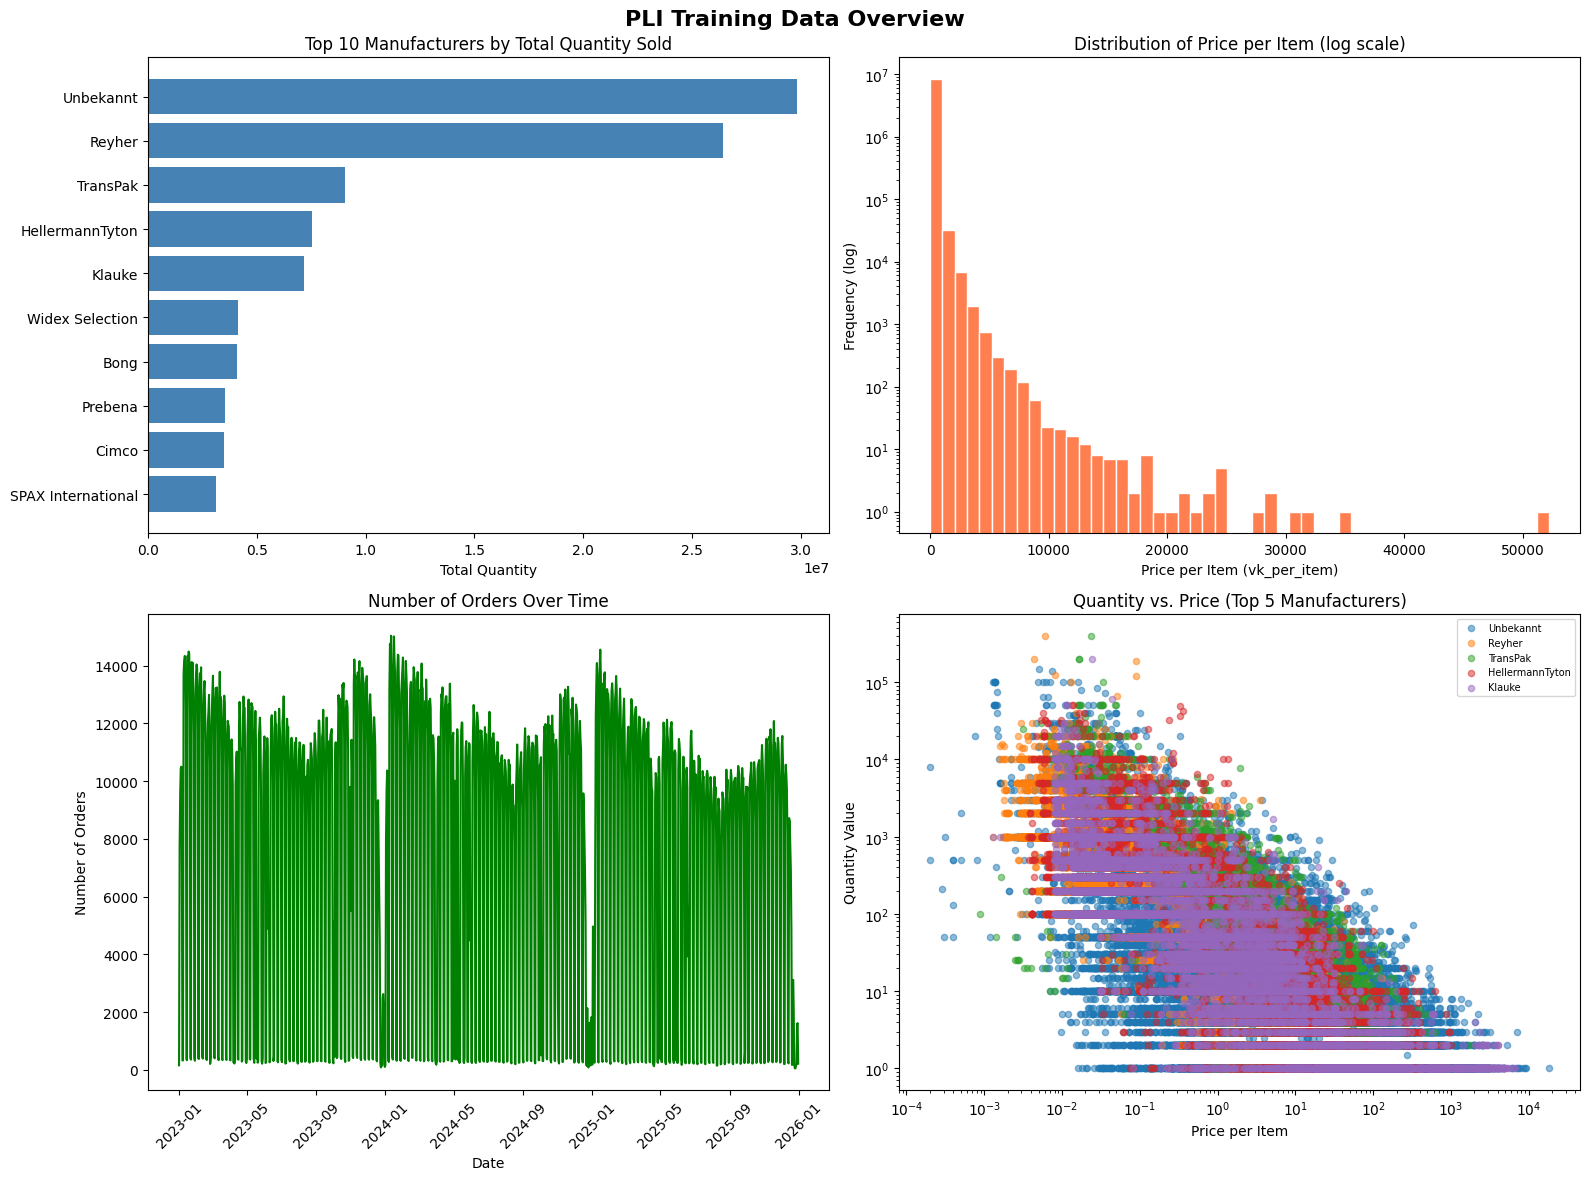

In [26]:


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PLI Training Data Overview', fontsize=16, fontweight='bold')

# 1. Top manufacturers by total quantity sold
top_manufacturers = (
    plis_training.groupby('manufacturer')['quantityvalue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
axes[0, 0].barh(top_manufacturers.index, top_manufacturers.values, color='steelblue')
axes[0, 0].set_title('Top 10 Manufacturers by Total Quantity Sold')
axes[0, 0].set_xlabel('Total Quantity')
axes[0, 0].invert_yaxis()

# 2. Distribution of vk_per_item (price per item) — log scale
axes[0, 1].hist(
    plis_training['vk_per_item'].dropna(),
    bins=50, color='coral', edgecolor='white', log=True
)
axes[0, 1].set_title('Distribution of Price per Item (log scale)')
axes[0, 1].set_xlabel('Price per Item (vk_per_item)')
axes[0, 1].set_ylabel('Frequency (log)')

# 3. Orders over time
plis_training['orderdate'] = pd.to_datetime(plis_training['orderdate'])
orders_over_time = plis_training.groupby('orderdate').size()
axes[1, 0].plot(orders_over_time.index, orders_over_time.values, color='green', linewidth=1.5)
axes[1, 0].set_title('Number of Orders Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Quantity vs. Price per item (scatter, top manufacturers)
top5 = top_manufacturers.head(5).index
subset = plis_training[plis_training['manufacturer'].isin(top5)]
for mfr in top5:
    data = subset[subset['manufacturer'] == mfr]
    axes[1, 1].scatter(
        data['vk_per_item'], data['quantityvalue'],
        label=mfr, alpha=0.5, s=20
    )
axes[1, 1].set_title('Quantity vs. Price (Top 5 Manufacturers)')
axes[1, 1].set_xlabel('Price per Item')
axes[1, 1].set_ylabel('Quantity Value')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [16]:
plis_training.describe()

,legal_entity_id,quantityvalue,vk_per_item,estimated_number_employees,nace_code,secondary_nace_code
count,8.373695e+06,8.373695e+06,8.373695e+06,7.914361e+06,8.243018e+06,3.954676e+06
mean,5.980591e+07,2.790604e+01,5.805029e+01,1.190005e+04,3.903482e+03,3.925410e+03
std,5.831634e+06,5.441516e+02,1.866440e+02,4.490054e+04,2.359174e+03,2.236482e+03
min,1.006370e+07,1.000000e+00,-1.074000e+01,1.000000e+00,1.000000e+00,7.000000e+00
25%,6.060535e+07,1.000000e+00,4.255000e+00,1.700000e+02,2.511000e+03,2.573000e+03
50%,6.112417e+07,2.000000e+00,1.400000e+01,6.000000e+02,3.020000e+03,3.513000e+03
75%,6.148140e+07,1.000000e+01,4.508000e+01,2.432000e+03,4.941000e+03,4.711000e+03
max,6.194945e+07,4.000000e+05,5.223711e+04,1.327349e+06,9.609000e+03,9.609000e+03


In [12]:
plis_training['eclass'].nunique()

8692

In [18]:
plis_training['manufacturer'].nunique()

20876

# nace_codes

In [21]:
nace_codes

,nace_code,n_nace_description,toplevel_section,toplevel_section_description,nace_2digits,nace_2digits_description,nace_3digits,nace_3digits_description
0,1,"Crop and animal production, hunting and relate...",A,"Agriculture, Forestry and Fishing",1,"Crop and animal production, hunting and relate...",NaN,NaN
1,11,Growing of non-perennial crops,A,"Agriculture, Forestry and Fishing",1,"Crop and animal production, hunting and relate...",11.0,Growing of non-perennial crops
2,111,"Growing of cereals (except rice), leguminous c...",A,"Agriculture, Forestry and Fishing",1,"Crop and animal production, hunting and relate...",11.0,Growing of non-perennial crops
3,112,Growing of rice,A,"Agriculture, Forestry and Fishing",1,"Crop and animal production, hunting and relate...",11.0,Growing of non-perennial crops
4,113,"Growing of vegetables and melons, roots and tu...",A,"Agriculture, Forestry and Fishing",1,"Crop and animal production, hunting and relate...",11.0,Growing of non-perennial crops
...,...,...,...,...,...,...,...,...
970,982,Undifferentiated service-producing activities ...,T,Activities of Households as Employers,98,Undifferentiated goods- and services-producing...,982.0,Undifferentiated service-producing activities ...
971,9820,Undifferentiated service-producing activities ...,T,Activities of Households as Employers,98,Undifferentiated goods- and services-producing...,982.0,Undifferentiated service-producing activities ...
972,99,Activities of extraterritorial organisations a...,U,Activities of Extraterritorial Organisations a...,99,Activities of extraterritorial organisations a...,NaN,NaN
973,990,Activities of extraterritorial organisations a...,U,Activities of Extraterritorial Organisations a...,99,Activities of extraterritorial organisations a...,990.0,Activities of extraterritorial organisations a...


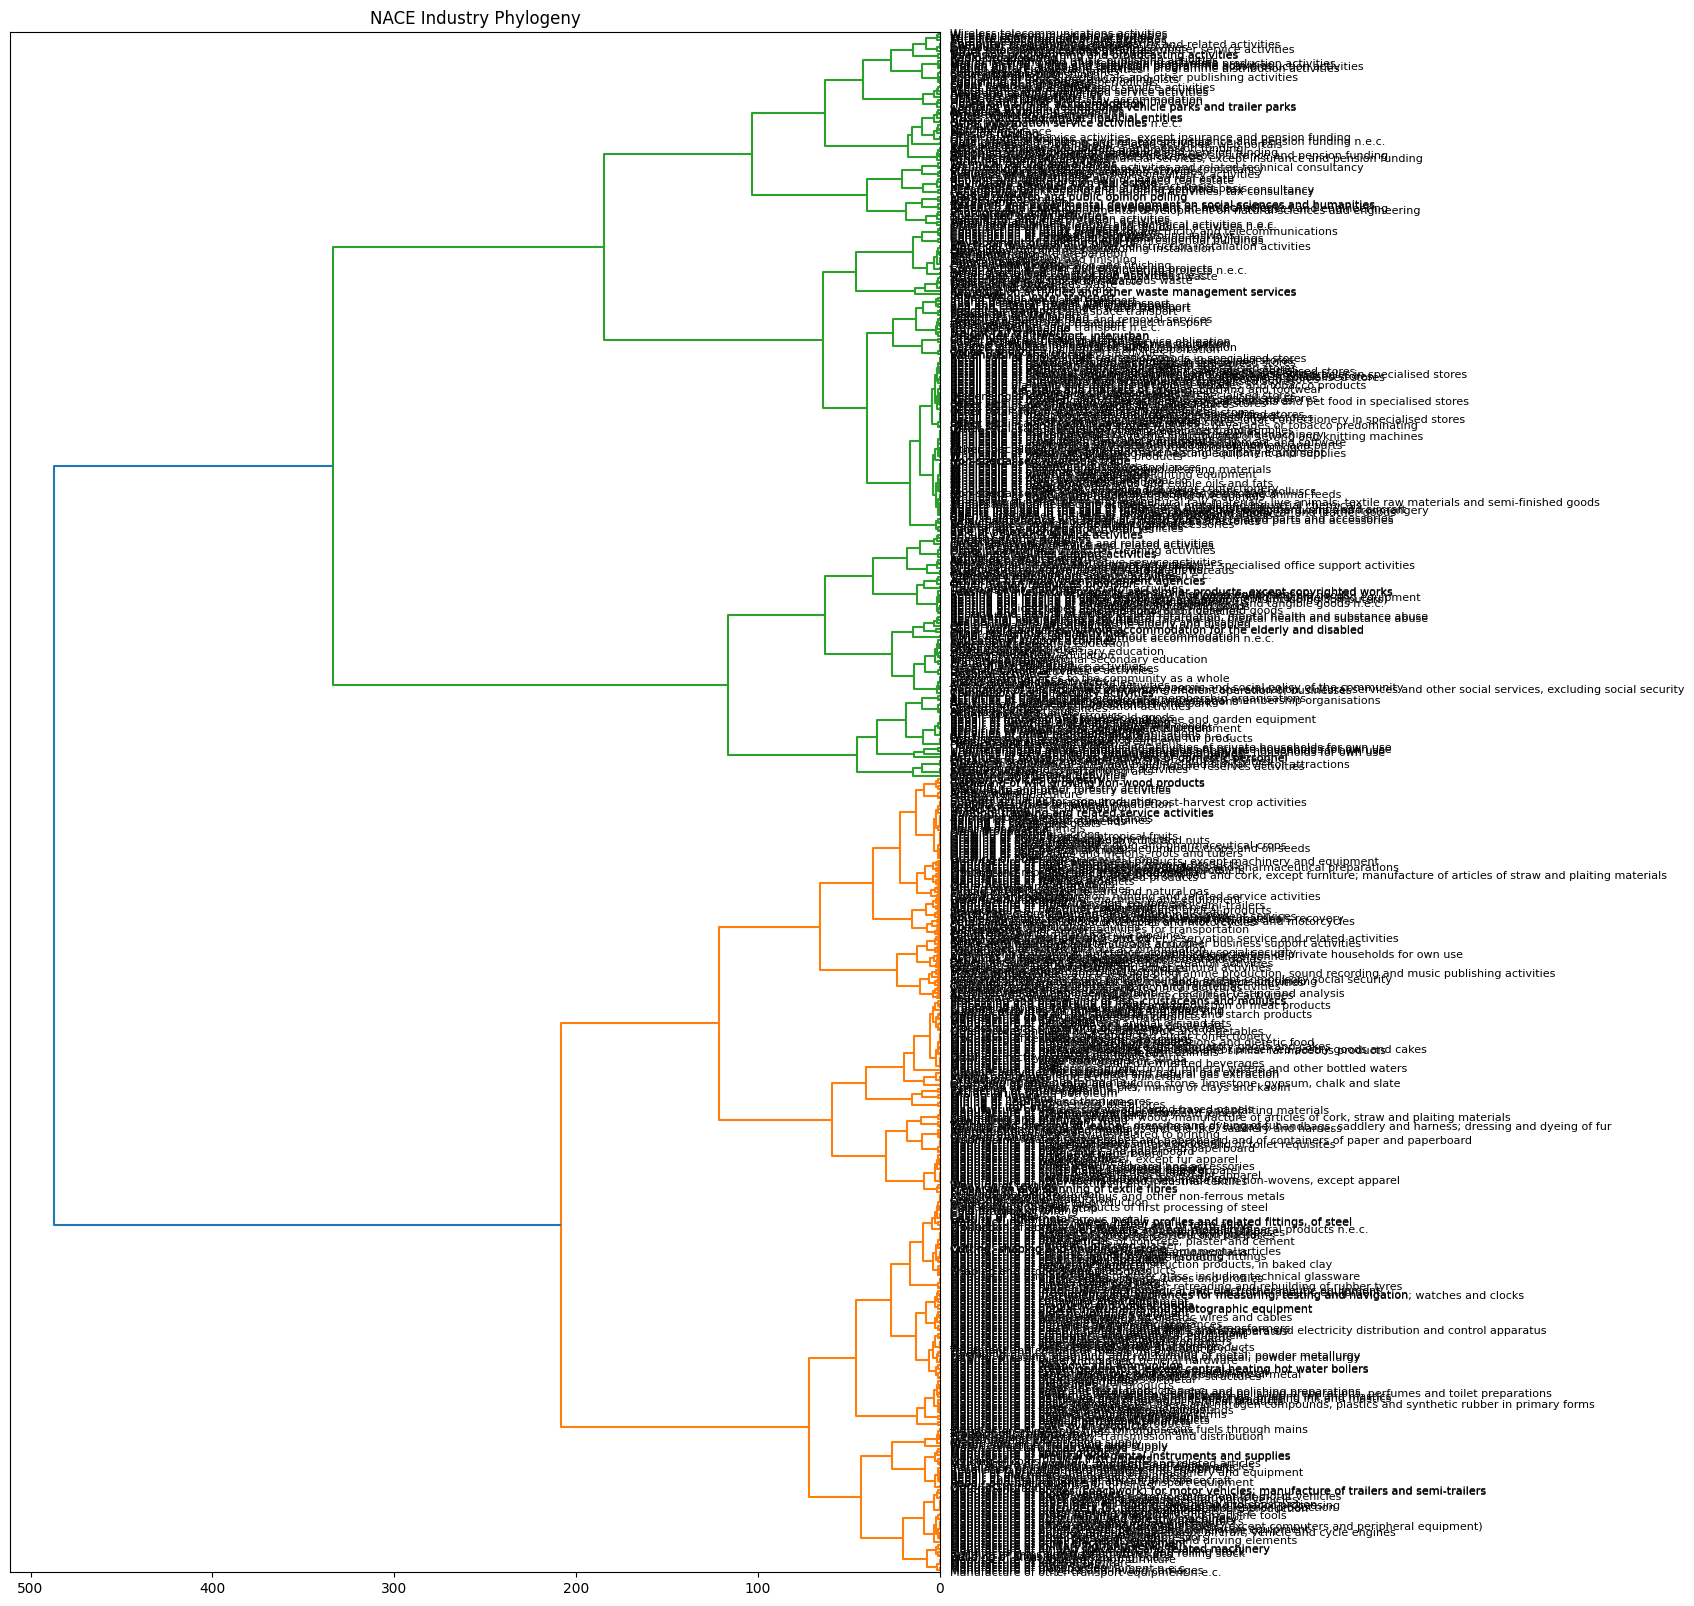

In [33]:

nace_codes['section_factor'] = pd.factorize(nace_codes['toplevel_section'])[0]


features = nace_codes[['section_factor', 'nace_2digits', 'nace_3digits']].fillna(0)

Z = sch.linkage(features, method='average')

# 4. Plot
plt.figure(figsize=(12, 20))
sch.dendrogram(Z, 
               labels=nace_codes['n_nace_description'].values, 
               orientation='left', 
               leaf_font_size=8)
plt.title("NACE Industry Phylogeny")
plt.show()

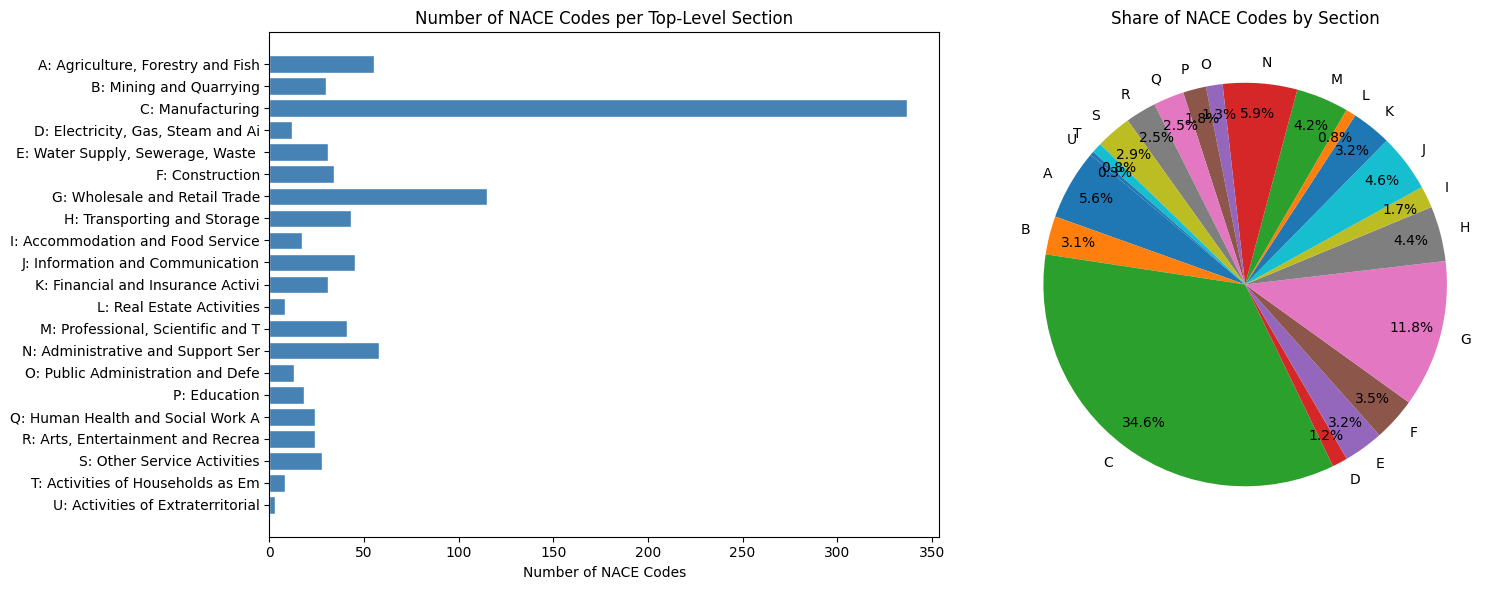

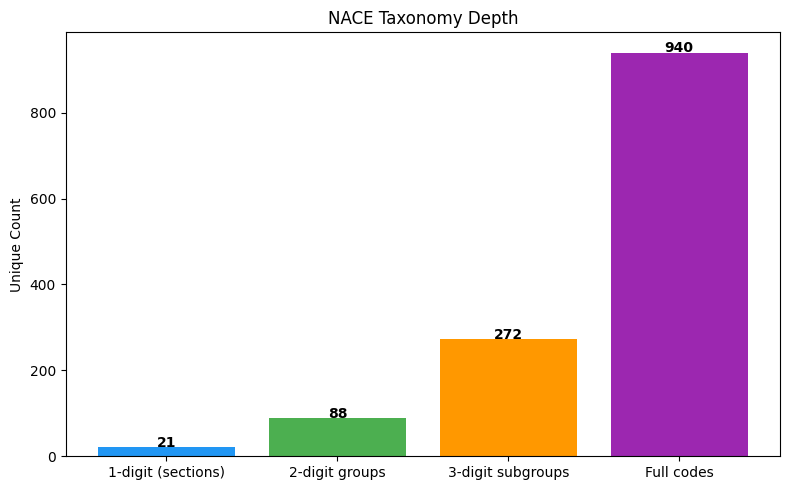

In [27]:

# --- Plot 1: Count of NACE codes per top-level section ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: number of codes per section
section_counts = nace_codes.groupby(['toplevel_section', 'toplevel_section_description']).size().reset_index(name='count')
section_counts['label'] = section_counts['toplevel_section'] + ': ' + section_counts['toplevel_section_description'].str[:30]

axes[0].barh(section_counts['label'], section_counts['count'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of NACE Codes')
axes[0].set_title('Number of NACE Codes per Top-Level Section')
axes[0].invert_yaxis()

# --- Plot 2: Pie chart of top-level sections ---
axes[1].pie(
    section_counts['count'],
    labels=section_counts['toplevel_section'],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85
)
axes[1].set_title('Share of NACE Codes by Section')

plt.tight_layout()
plt.savefig('nace_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Depth breakdown (1-digit, 2-digit, 3-digit codes) ---
fig, ax = plt.subplots(figsize=(8, 5))

depth_counts = {
    '1-digit (sections)': nace_codes['toplevel_section'].nunique(),
    '2-digit groups':     nace_codes['nace_2digits'].nunique(),
    '3-digit subgroups':  nace_codes['nace_3digits'].dropna().nunique(),
    'Full codes':         nace_codes['nace_code'].nunique(),
}

ax.bar(depth_counts.keys(), depth_counts.values(), color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
ax.set_ylabel('Unique Count')
ax.set_title('NACE Taxonomy Depth')
for i, (k, v) in enumerate(depth_counts.items()):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('nace_depth.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
nace_codes.describe()

,nace_code,nace_2digits,nace_3digits
count,975.000000,975.000000,887.000000
mean,2802.815385,43.513846,432.387824
std,2837.638859,27.253309,269.517051
min,1.000000,1.000000,11.000000
25%,331.500000,23.000000,233.000000
50%,1920.000000,43.000000,431.000000
75%,4672.500000,64.500000,641.000000
max,9900.000000,99.000000,990.000000


In [22]:
nace_codes['n_nace_description'].nunique()

823

In [23]:
nace_codes['toplevel_section'].nunique()

21

In [24]:
nace_codes['toplevel_section_description'].nunique()

21

# features_per_sku

In [35]:
features_per_sku

,safe_synonym,sku,key,fvalue,fvalue_set
0,1000_10_zusatzzeichen_,114-7428,Folie-_verkehrsschilder_folie,RA0,RA0
1,1000_10_zusatzzeichen_,164-74054,Folie-_verkehrsschilder_folie,RA1,RA1
2,1000_10_zusatzzeichen_,5921-A120.20.405,Folie-_verkehrsschilder_folie,RA1,RA1
3,1000_10_zusatzzeichen_,5921-A120.20.406,Folie-_verkehrsschilder_folie,RA1,RA1
4,1000_10_zusatzzeichen_,602-Z1000-10 6121,Folie-_verkehrsschilder_folie,RA1,RA1
...,...,...,...,...,...
18115008,zweilippendichtung,223-0605299,Au(df)en(2d)(d8)-durchmesser_mm_aussen___indik...,157.5,157.5
18115009,zweilippendichtung,2302-A00010602,Au(df)en(2d)(d8)-durchmesser_mm_aussen___indik...,NaN,140.93
18115010,zweilippendichtung,223-0605299,Breite-breite_mm_alt___sonderindikatorvor(2c)(...,15,15
18115011,zweilippendichtung,223-0605299,Innen(2d)(d8)-durchmesser_mm_innen___indikator...,99,99


In [36]:
features_per_sku['safe_synonym'].nunique()

20344

In [37]:
features_per_sku['key'].nunique()

14286

In [38]:
features_per_sku['fvalue'].nunique()

31094

# customer_test

In [30]:
customer_test.head()

,legal_entity_id,estimated_number_employees,nace_code,secondary_nace_code,task
0,41361768,6546.0,861,NaN,cold start
1,41525307,630.0,3511,NaN,cold start
2,60218513,1919.0,1089,NaN,cold start
3,60229572,1050.0,2841,4674.0,cold start
4,60232585,1313.0,2222,NaN,cold start


mitual information between probuct and company 

# model

In [ ]:
'''

model: company (nace), history, fixed free , saveing rate ,  

    return product, date


'''